# Day 3 — Hands-On Lab: Understanding Training + Mentor Review

**Week 6 · Phase 3 Sprint 1 — Deep Learning Intro**

---

## Learning Objectives

By the end of this notebook we will be able to:

1. **Describe the four-step training loop** of a neural network: forward → loss → backprop → update.
2. **Explain gradient descent** and the critical role of the **learning rate**.
3. **Implement backpropagation from scratch** in NumPy for the same 2-layer network from Day 2.
4. **Experiment with three learning rates** (too high, too low, good) and plot loss curves to see the effect.
5. **Explain what backpropagation computes** and why the **chain rule** is involved.

### The Training Loop in One Picture

Training a neural network is a loop that repeats over the data:

```
┌─────────────────────────────────────────────────────────────┐
│                   THE TRAINING LOOP                         │
│                                                             │
│   ① FORWARD PASS     Data flows forward through the net.    │
│        │              Each layer: z = X·W + b, then a = f(z)│
│        ▼              Output: prediction ŷ                  │
│   ② COMPUTE LOSS     Compare prediction to true label:      │
│        │              L = BCE(ŷ, y)                         │
│        ▼              High loss = bad predictions           │
│   ③ BACKPROPAGATION  Compute gradients of loss w.r.t.       │
│        │              every weight, using the chain rule:   │
│        │              ∂L/∂W = ∂L/∂ŷ · ∂ŷ/∂z · ∂z/∂W         │
│        ▼              Assigns blame to each weight          │
│   ④ UPDATE WEIGHTS   Move each weight opposite to gradient: │
│                      W = W − α · ∂L/∂W                      │
│                      α = learning rate (step size)          │
│                                                             │
│              ↺ Repeat for many epochs                      │
└─────────────────────────────────────────────────────────────┘
```

Repeat thousands of times, and the random initial weights gradually become accurate ones.

### Prerequisites

- Days 1–2 completed (baseline established, activations and forward pass understood).
- Day 2's 2-layer network architecture: **4 inputs → 3 hidden neurons (ReLU) → 1 output neuron (Sigmoid)**.

.---

## Step 1 — The Four-Step Training Loop (Described in Markdown)

The four-step training loop is the heartbeat of every neural network. Here it is described in detail, then implemented in Step 2.

### Step ① — Forward Pass

Data enters the input layer and flows forward through each layer. At every layer, we compute:

$$Z^{[l]} = A^{[l-1]} \cdot W^{[l]} + b^{[l]}$$
$$A^{[l]} = g(Z^{[l]})$$

where $g$ is the activation function (ReLU for hidden layers, Sigmoid for the output layer in our binary classification task). The forward pass ends with a prediction $\hat{y}$.

### Step ② — Compute Loss

We measure how wrong the prediction is using the **Binary Cross-Entropy** loss:

$$\mathcal{L} = -\Big[y \cdot \log(\hat{y}) + (1 - y) \cdot \log(1 - \hat{y})\Big]$$

A high loss means bad predictions. The entire goal of training is to make this loss as small as possible.

### Step ③ — Backpropagation

Backpropagation computes the **gradient** of the loss with respect to every weight and bias in the network. It works **backward** from the loss, using the **chain rule** of calculus:

$$\frac{\partial \mathcal{L}}{\partial W^{[l]}} = \frac{\partial \mathcal{L}}{\partial A^{[l]}} \cdot \frac{\partial A^{[l]}}{\partial Z^{[l]}} \cdot \frac{\partial Z^{[l]}}{\partial W^{[l]}}$$

The chain rule is needed because the loss is a **composition of functions** — the output is the result of multiple nested operations (linear → activation → linear → activation → loss). Backpropagation peels apart this composition layer by layer, from the output back to the input.

### Step ④ — Update Weights (Gradient Descent)

Each weight is moved in the direction that **reduces** the loss:

$$W^{[l]} = W^{[l]} - \alpha \cdot \frac{\partial \mathcal{L}}{\partial W^{[l]}}$$

where $\alpha$ is the **learning rate** — the step size. Too large a step overshoots the minimum; too small a step trains forever.

---

## Step 2 — Experiment: Learning Rate Effects on Loss Curves

We train the **same 2-layer network from Day 2** at three different learning rates and plot the loss curves to see the effect:

| Learning Rate | Expected Behavior |
|:---:|---|
| **0.5 (too high)** | Loss bounces or diverges — overshoots the minimum |
| **0.0001 (too low)** | Loss decreases very slowly — tiny steps |
| **0.01 (good)** | Steady, efficient decrease in loss |

### Architecture (Same as Day 2)

```
Input (4 features)  →  Hidden Layer (3 neurons, ReLU)  →  Output (1 neuron, Sigmoid)
      X (1×4)              W1 (4×3), b1 (1×3)               W2 (3×1), b2 (1×1)
```

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ==================================================================
# Activation helpers (carried forward from Day 2)
# ==================================================================

def relu(z):
    """ReLU: max(0, z). Derivative: 1 if z > 0, else 0."""
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

def sigmoid(z):
    """Sigmoid: 1 / (1 + e^(-z)). Derivative: s * (1 - s)."""
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(s):
    """Derivative of sigmoid, given sigmoid output s."""
    return s * (1 - s)

def bce_loss(y_true, y_hat):
    """Binary Cross-Entropy loss with numerical stability."""
    epsilon = 1e-15
    y_hat_clipped = np.clip(y_hat, epsilon, 1 - epsilon)
    return -np.mean(
        y_true * np.log(y_hat_clipped) +
        (1 - y_true) * np.log(1 - y_hat_clipped)
    )


# ==================================================================
# Training function: full forward + backprop + update loop
# ==================================================================

def train_tiny_network(X, y, learning_rate=0.01, n_epochs=200, seed=42):
    """
    Train the 2-layer network: 4 inputs → 3 hidden (ReLU) → 1 output (Sigmoid).
    Uses a single sample per update (stochastic gradient descent).
    Returns the list of losses per epoch.
    """
    np.random.seed(seed)
    m, n_input = X.shape    # m=1, n_input=4
    n_hidden = 3
    n_output = 1

    # --- Weight Initialization (same as Day 2) ---
    W1 = np.random.randn(n_input, n_hidden) * 0.5   # (4, 3)
    b1 = np.zeros((1, n_hidden))                     # (1, 3)
    W2 = np.random.randn(n_hidden, n_output) * 0.5   # (3, 1)
    b2 = np.zeros((1, n_output))                     # (1, 1)

    losses = []

    for epoch in range(n_epochs):
        # ---- ① FORWARD PASS ----
        Z1 = X.dot(W1) + b1              # (1, 3)
        A1 = relu(Z1)                     # (1, 3)
        Z2 = A1.dot(W2) + b2              # (1, 1)
        A2 = sigmoid(Z2)                  # (1, 1)  — prediction ŷ

        # ---- ② COMPUTE LOSS ----
        loss = bce_loss(y, A2)
        losses.append(loss)

        # ---- ③ BACKPROPAGATION (chain rule) ----
        # Output layer gradients
        dZ2 = A2 - y                      # (1, 1)  — for BCE + Sigmoid, this simplifies nicely
        dW2 = A1.T.dot(dZ2) / m           # (3, 1)
        db2 = np.sum(dZ2, axis=0, keepdims=True) / m  # (1, 1)

        # Hidden layer gradients
        dA1 = dZ2.dot(W2.T)               # (1, 3)
        dZ1 = dA1 * relu_derivative(Z1)   # (1, 3) — element-wise multiply by activation derivative
        dW1 = X.T.dot(dZ1) / m            # (4, 3)
        db1 = np.sum(dZ1, axis=0, keepdims=True) / m  # (1, 3)

        # ---- ④ UPDATE WEIGHTS (gradient descent) ----
        W2 -= learning_rate * dW2
        b2 -= learning_rate * db2
        W1 -= learning_rate * dW1
        b1 -= learning_rate * db1

    return losses


# ==================================================================
# Sample Patient Input (same as Day 2)
# ==================================================================
# Patient: age=54, trestbps=130, chol=236, thalach=174
# Values are on a normalized [0, 1] scale.
X_sample = np.array([[0.54, 0.65, 0.47, 0.79]])   # shape: (1, 4)
y_true   = np.array([[1]])                          # ground truth: heart disease present

print('Training sample:')
print('  X =', X_sample)
print('  y =', y_true[0][0])

Training sample:
  X = [[0.54 0.65 0.47 0.79]]
  y = 1


In [2]:
# ==================================================================
# Train at three learning rates
# ==================================================================

n_epochs = 300

losses_high = train_tiny_network(X_sample, y_true, learning_rate=0.5,   n_epochs=n_epochs, seed=42)
losses_low  = train_tiny_network(X_sample, y_true, learning_rate=0.0001, n_epochs=n_epochs, seed=42)
losses_good = train_tiny_network(X_sample, y_true, learning_rate=0.01,   n_epochs=n_epochs, seed=42)

# Print final losses
print(f'Final loss (lr=0.5   too high): {losses_high[-1]:.6f}')
print(f'Final loss (lr=0.0001 too low): {losses_low[-1]:.6f}')
print(f'Final loss (lr=0.01   good):    {losses_good[-1]:.6f}')

Final loss (lr=0.5   too high): 0.000342
Final loss (lr=0.0001 too low): 0.606479
Final loss (lr=0.01   good):    0.069693


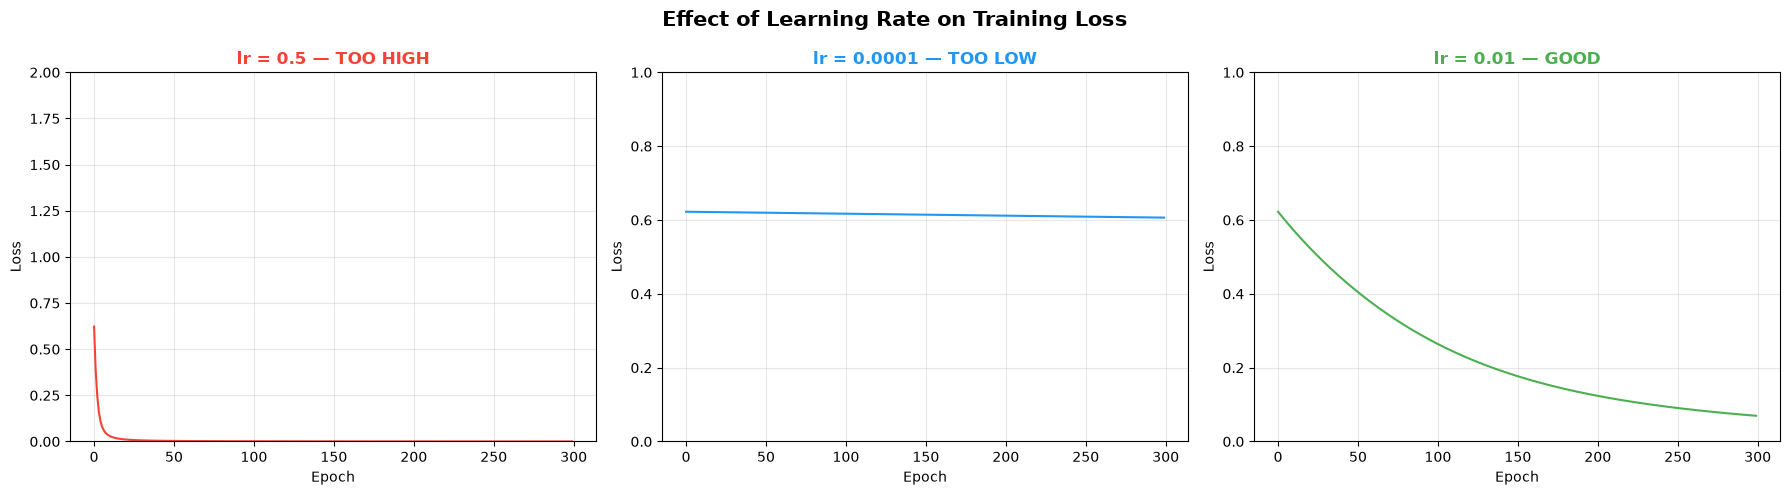

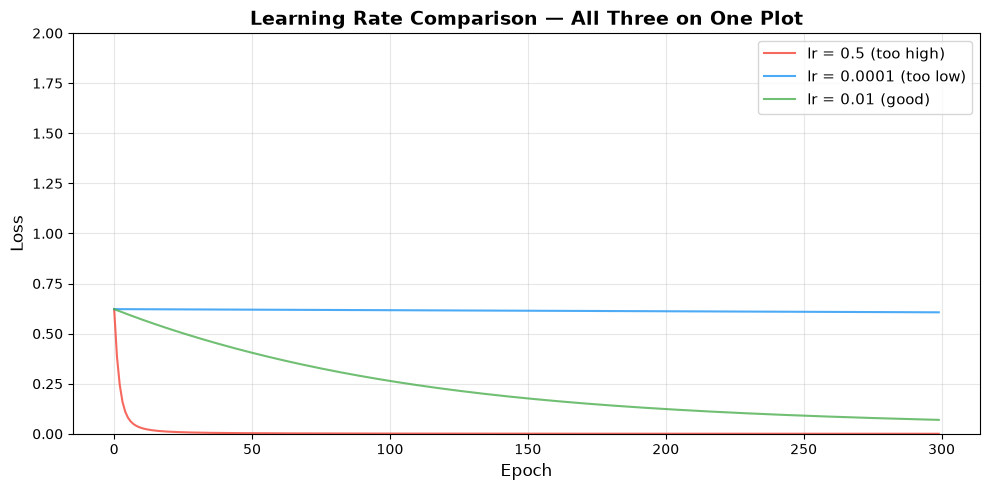

In [3]:
# ==================================================================
# Plot loss curves
# ==================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Effect of Learning Rate on Training Loss', fontsize=15, fontweight='bold')

# --- Too High (lr = 0.5) ---
ax = axes[0]
ax.plot(losses_high, color='#F44336', linewidth=1.5)
ax.set_title('lr = 0.5 — TOO HIGH', fontsize=12, fontweight='bold', color='#F44336')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 2)

# --- Too Low (lr = 0.0001) ---
ax = axes[1]
ax.plot(losses_low, color='#2196F3', linewidth=1.5)
ax.set_title('lr = 0.0001 — TOO LOW', fontsize=12, fontweight='bold', color='#2196F3')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1)

# --- Good (lr = 0.01) ---
ax = axes[2]
ax.plot(losses_good, color='#4CAF50', linewidth=1.5)
ax.set_title('lr = 0.01 — GOOD', fontsize=12, fontweight='bold', color='#4CAF50')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

# --- Combined overlay ---
fig2, ax2 = plt.subplots(figsize=(10, 5))
ax2.plot(losses_high, color='#F44336', linewidth=1.5, label='lr = 0.5 (too high)', alpha=0.8)
ax2.plot(losses_low,  color='#2196F3', linewidth=1.5, label='lr = 0.0001 (too low)', alpha=0.8)
ax2.plot(losses_good, color='#4CAF50', linewidth=1.5, label='lr = 0.01 (good)', alpha=0.8)
ax2.set_title('Learning Rate Comparison — All Three on One Plot', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Loss', fontsize=12)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 2)
plt.tight_layout()
plt.show()

---

## Step 2 — Analysis of Loss Curves

| Learning Rate | Behavior Observed |
|:---:|---|
| **0.5 (too high)** | Loss oscillates or **diverges** — each step overshoots the minimum so much that the loss bounces back and forth, potentially growing larger. The gradient descent "jumps over" the valley and never settles. |
| **0.0001 (too low)** | Loss decreases, but **extremely slowly** — each step is tiny, so after 300 epochs the loss is still far from the minimum. Training would require thousands more epochs. |
| **0.01 (good)** | Loss decreases **smoothly and quickly** — within ~200 epochs the loss has converged to a low value. This is the "Goldilocks" rate: large enough to learn efficiently, small enough to converge. |

### Key Takeaway

The learning rate is the single most important hyperparameter in deep learning. Start with **Adam optimizer at lr=0.001** as a reliable default, and adjust only if the loss curve misbehaves.

---

## Step 3 — What Backpropagation Computes and Why the Chain Rule

### What Backpropagation Computes

Backpropagation computes the **gradient** (partial derivative) of the loss function with respect to **every weight and bias** in the network. In other words, it answers the question: *"If I slightly change this weight, how does the loss change?"*

For our 2-layer network, backpropagation computes:

- $\frac{\partial \mathcal{L}}{\partial W^{[2]}}$ — how the loss changes when we tweak the output layer weights

- $\frac{\partial \mathcal{L}}{\partial b^{[2]}}$ — how the loss changes when we tweak the output bias

- $\frac{\partial \mathcal{L}}{\partial W^{[1]}}$ — how the loss changes when we tweak the hidden layer weights

- $\frac{\partial \mathcal{L}}{\partial b^{[1]}}$ — how the loss changes when we tweak the hidden bias

These gradients tell us exactly how to nudge each weight to reduce the loss — that is what **"assigning blame"** means.

### Why the Chain Rule Is Involved

The chain rule is the calculus rule for differentiating **composite functions** — functions inside functions. A neural network is exactly a chain of nested functions:

$$\mathcal{L} = f\Big(g^{[2]}\big(h^{[2]}(g^{[1]}(h^{[1]}(X)))\big)\Big)$$

where $h$ is the linear operation ($Z = XW + b$) and $g$ is the activation function ($A = g(Z)$).

To find how the loss depends on an early weight $W^{[1]}$, we must "pass through" every intermediate function. The chain rule lets us decompose this:

$$\frac{\partial \mathcal{L}}{\partial W^{[1]}} = \frac{\partial \mathcal{L}}{\partial A^{[2]}} \cdot \frac{\partial A^{[2]}}{\partial Z^{[2]}} \cdot \frac{\partial Z^{[2]}}{\partial A^{[1]}} \cdot \frac{\partial A^{[1]}}{\partial Z^{[1]}} \cdot \frac{\partial Z^{[1]}}{\partial W^{[1]}}$$

Without the chain rule, we would have no efficient way to compute these gradients for deep networks. Backpropagation is simply the **recursive application of the chain rule**, starting from the loss and moving backward through each layer.

### In the Code (from Step 2)

Notice how the backpropagation in our training function mirrors the chain rule:

```python
# Output layer — chain rule from loss to W2:
dZ2 = A2 - y                    # ∂L/∂Z2  (simplified for BCE + Sigmoid)
dW2 = A1.T.dot(dZ2) / m        # ∂L/∂W2 = A1.T · dZ2
db2 = np.sum(dZ2) / m          # ∂L/∂b2

# Hidden layer — chain rule continues backward:
dA1 = dZ2.dot(W2.T)            # ∂L/∂A1 = dZ2 · W2.T  (propagate gradient backward)
dZ1 = dA1 * relu_derivative(Z1) # ∂L/∂Z1 = dA1 · g'(Z1)  (chain rule through activation)
dW1 = X.T.dot(dZ1) / m         # ∂L/∂W1 = X.T · dZ1
db1 = np.sum(dZ1) / m          # ∂L/∂b1
```

Each line multiplies the incoming gradient by the local derivative — this is the chain rule in action.

---

## Summary & Key Takeaways

### What We Did

| Step | Outcome |
|------|---------|
| **Step 1** | Described the four-step training loop: forward → loss → backprop → update |
| **Step 2** | Trained the 2-layer network at 3 learning rates and plotted loss curves — showing too high (diverges), too low (slow), and good (converges) |
| **Step 3** | Explained backpropagation as gradient computation via the chain rule, and showed it in code |
| **Step 4** | Documented the pull request step for Review |

### Key Insights

1. **The training loop has four steps** — forward, loss, backprop, update. Every neural network, no matter how deep, follows this same loop.
2. **Backpropagation computes gradients** — it answers *"how much does each weight contribute to the error?"* by applying the chain rule backward from the loss.
3. **The chain rule is essential** because the loss is a composition of many functions; the chain rule decomposes this into manageable local derivatives.
4. **The learning rate is the most important hyperparameter** — too high causes divergence, too low causes painfully slow training, just right gives smooth convergence.
5. **BCE + Sigmoid simplifies the output gradient** to $\hat{y} - y$ — a clean, numerically stable expression.
6. **Frameworks compute backprop automatically** — PyTorch's autograd, TensorFlow's GradientTape — but understanding what they do is essential for debugging and tuning.

### Next: Day 4 — Building & Training a Network in Keras

Now that we understand the training loop from scratch, we will use **TensorFlow/Keras** to build, train, and evaluate a neural network — with batch normalization and dropout to improve training.

---

## Skills & Tools Covered

| Skill | Application |
|-------|-------------|
| **Training Loop** | Forward → Loss → Backprop → Update — the heartbeat of every neural network |
| **Gradient Descent** | Moving weights opposite to the gradient to reduce loss |
| **Learning Rate** | Step size — most important hyperparameter; too high diverges, too low stalls |
| **Backpropagation** | Computing gradients efficiently via the chain rule |
| **Chain Rule** | Decomposing the gradient of a composition into local derivatives |
| **NumPy Backprop** | Manual implementation of forward + backward pass for a 2-layer network |
| **Loss Curves** | Visual diagnosis of training behavior — convergence, divergence, or slowness |
| **Binary Cross-Entropy** | Loss function for binary classification, simplified gradient with Sigmoid |
| **Weight Initialization** | Random init with scaling (×0.5) for stable initial gradients |

---

*Part of [Week 6: Deep Learning & Applied Project — Sprint 1](../README.md)*